<a href="https://colab.research.google.com/github/Hend-Cheikhrouhou/Machine_Learning/blob/main/projetESG_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESG Risk Analysis: Insights from S&P 500 Companies

In [ ]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn import manifold
from sklearn.metrics import accuracy_score



In [ ]:
#Chargement de l'ensemble de données
df=pd.read_csv('/content/sp500_esg_data.csv')

In [ ]:
df.head()

,Symbol,Full Name,GICS Sector,GICS Sub-Industry,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,percentile,ratingYear,ratingMonth,marketCap,beta,overallRisk
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,1.12,6.42,6.10,13.64,2.0,7.98,2023.0,9.0,39751831552,1.054,8
1,AAL,American Airlines Group,Industrials,Passenger Airlines,9.94,11.65,4.76,26.35,2.0,54.48,2023.0,9.0,7335383552,1.433,10
2,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals",0.46,7.39,9.37,17.22,3.0,17.82,2023.0,9.0,3296096681984,1.240,1
3,ABBV,AbbVie,Health Care,Biotechnology,2.38,17.19,10.36,29.93,3.0,68.62,2023.0,9.0,341698445312,0.619,6
4,ABT,Abbott Laboratories,Health Care,Health Care Equipment,2.27,14.24,8.33,24.83,3.0,48.27,2023.0,9.0,205534380032,0.722,7


In [ ]:
df.shape

(426, 15)

In [ ]:
print("\nInformations générales :")
print(df.info())


Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Symbol              426 non-null    object 
 1   Full Name           426 non-null    object 
 2   GICS Sector         426 non-null    object 
 3   GICS Sub-Industry   426 non-null    object 
 4   environmentScore    426 non-null    float64
 5   socialScore         426 non-null    float64
 6   governanceScore     426 non-null    float64
 7   totalEsg            426 non-null    float64
 8   highestControversy  426 non-null    float64
 9   percentile          426 non-null    float64
 10  ratingYear          426 non-null    float64
 11  ratingMonth         426 non-null    float64
 12  marketCap           426 non-null    int64  
 13  beta                426 non-null    float64
 14  overallRisk         426 non-null    int64  
dtypes: float64(9), int64(2), object

In [ ]:
print("\nNoms des colonnes :")
print(df.columns)


Noms des colonnes :
Index(['Symbol', 'Full Name', 'GICS Sector', 'GICS Sub-Industry',
       'environmentScore', 'socialScore', 'governanceScore', 'totalEsg',
       'highestControversy', 'percentile', 'ratingYear', 'ratingMonth',
       'marketCap', 'beta', 'overallRisk'],
      dtype='object')




---



>  la variable cible est 'totalEsg'  

---





In [ ]:
# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
Symbol                0
Full Name             0
GICS Sector           0
GICS Sub-Industry     0
environmentScore      0
socialScore           0
governanceScore       0
totalEsg              0
highestControversy    0
percentile            0
ratingYear            0
ratingMonth           0
marketCap             0
beta                  0
overallRisk           0
dtype: int64




*  aucun enregistrement vide



In [ ]:
# Description statistique des colonnes numériques
print("\nStatistiques descriptives :")
print(df.describe())


Statistiques descriptives :
       environmentScore  socialScore  governanceScore    totalEsg  \
count        426.000000   426.000000       426.000000  426.000000   
mean           5.784343     9.071009         6.701009   21.556150   
std            5.091763     3.663293         2.165417    6.898711   
min            0.000000     0.760000         2.960000    7.080000   
25%            1.780000     6.662500         5.252500   16.410000   
50%            4.085000     8.905000         6.085000   21.070000   
75%            8.992500    11.212500         7.637500   26.020000   
max           24.980000    22.480000        19.430000   41.660000   

       highestControversy  percentile   ratingYear  ratingMonth     marketCap  \
count          426.000000  426.000000   426.000000   426.000000  4.260000e+02   
mean             1.882629   35.766150  2022.978873     8.960094  1.094058e+11   
std              0.910244   24.307081     0.198878     0.455868  3.112613e+11   
min              0.000000

In [ ]:
print("\nStatistiques descriptives des colonnes catégoriques :")
print(df.describe(include='object'))


Statistiques descriptives des colonnes catégoriques :
       Symbol             Full Name GICS Sector      GICS Sub-Industry
count     426                   426         426                    426
unique    426                   426          11                    119
top         A  Agilent Technologies  Financials  Health Care Equipment
freq        1                     1          65                     15


*  La majorité des distributions ne sont pas normales.Cela est particulièrement vrai pour marketCap, environmentScore et totalEsg, qui présentent des asymétries positives importantes.
*  Certaines variables, comme socialScore, governanceScore, et beta, pourraient être plus proches d’une normalité mais avec des distributions possiblement légèrement asymétriques.


**Encodage des colonnes non numériques**




In [ ]:
from sklearn.preprocessing import LabelEncoder
# Créer une instance de LabelEncoder
le = LabelEncoder()
# Encoder les colonnes non numériques
df['Symbol'] = le.fit_transform(df['Symbol'])
df['Full Name'] = le.fit_transform(df['Full Name'])
df['GICS Sector'] = le.fit_transform(df['GICS Sector'])
df['GICS Sub-Industry'] = le.fit_transform(df['GICS Sub-Industry'])
df.head()

,Symbol,Full Name,GICS Sector,GICS Sub-Industry,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,percentile,ratingYear,ratingMonth,marketCap,beta,overallRisk
0,0,10,5,75,1.12,6.42,6.10,13.64,2.0,7.98,2023.0,9.0,39751831552,1.054,8
1,1,22,6,91,9.94,11.65,4.76,26.35,2.0,54.48,2023.0,9.0,7335383552,1.433,10
2,2,34,7,111,0.46,7.39,9.37,17.22,3.0,17.82,2023.0,9.0,3296096681984,1.240,1
3,3,5,5,12,2.38,17.19,10.36,29.93,3.0,68.62,2023.0,9.0,341698445312,0.619,6
4,4,6,5,48,2.27,14.24,8.33,24.83,3.0,48.27,2023.0,9.0,205534380032,0.722,7


**Distribution des variables**

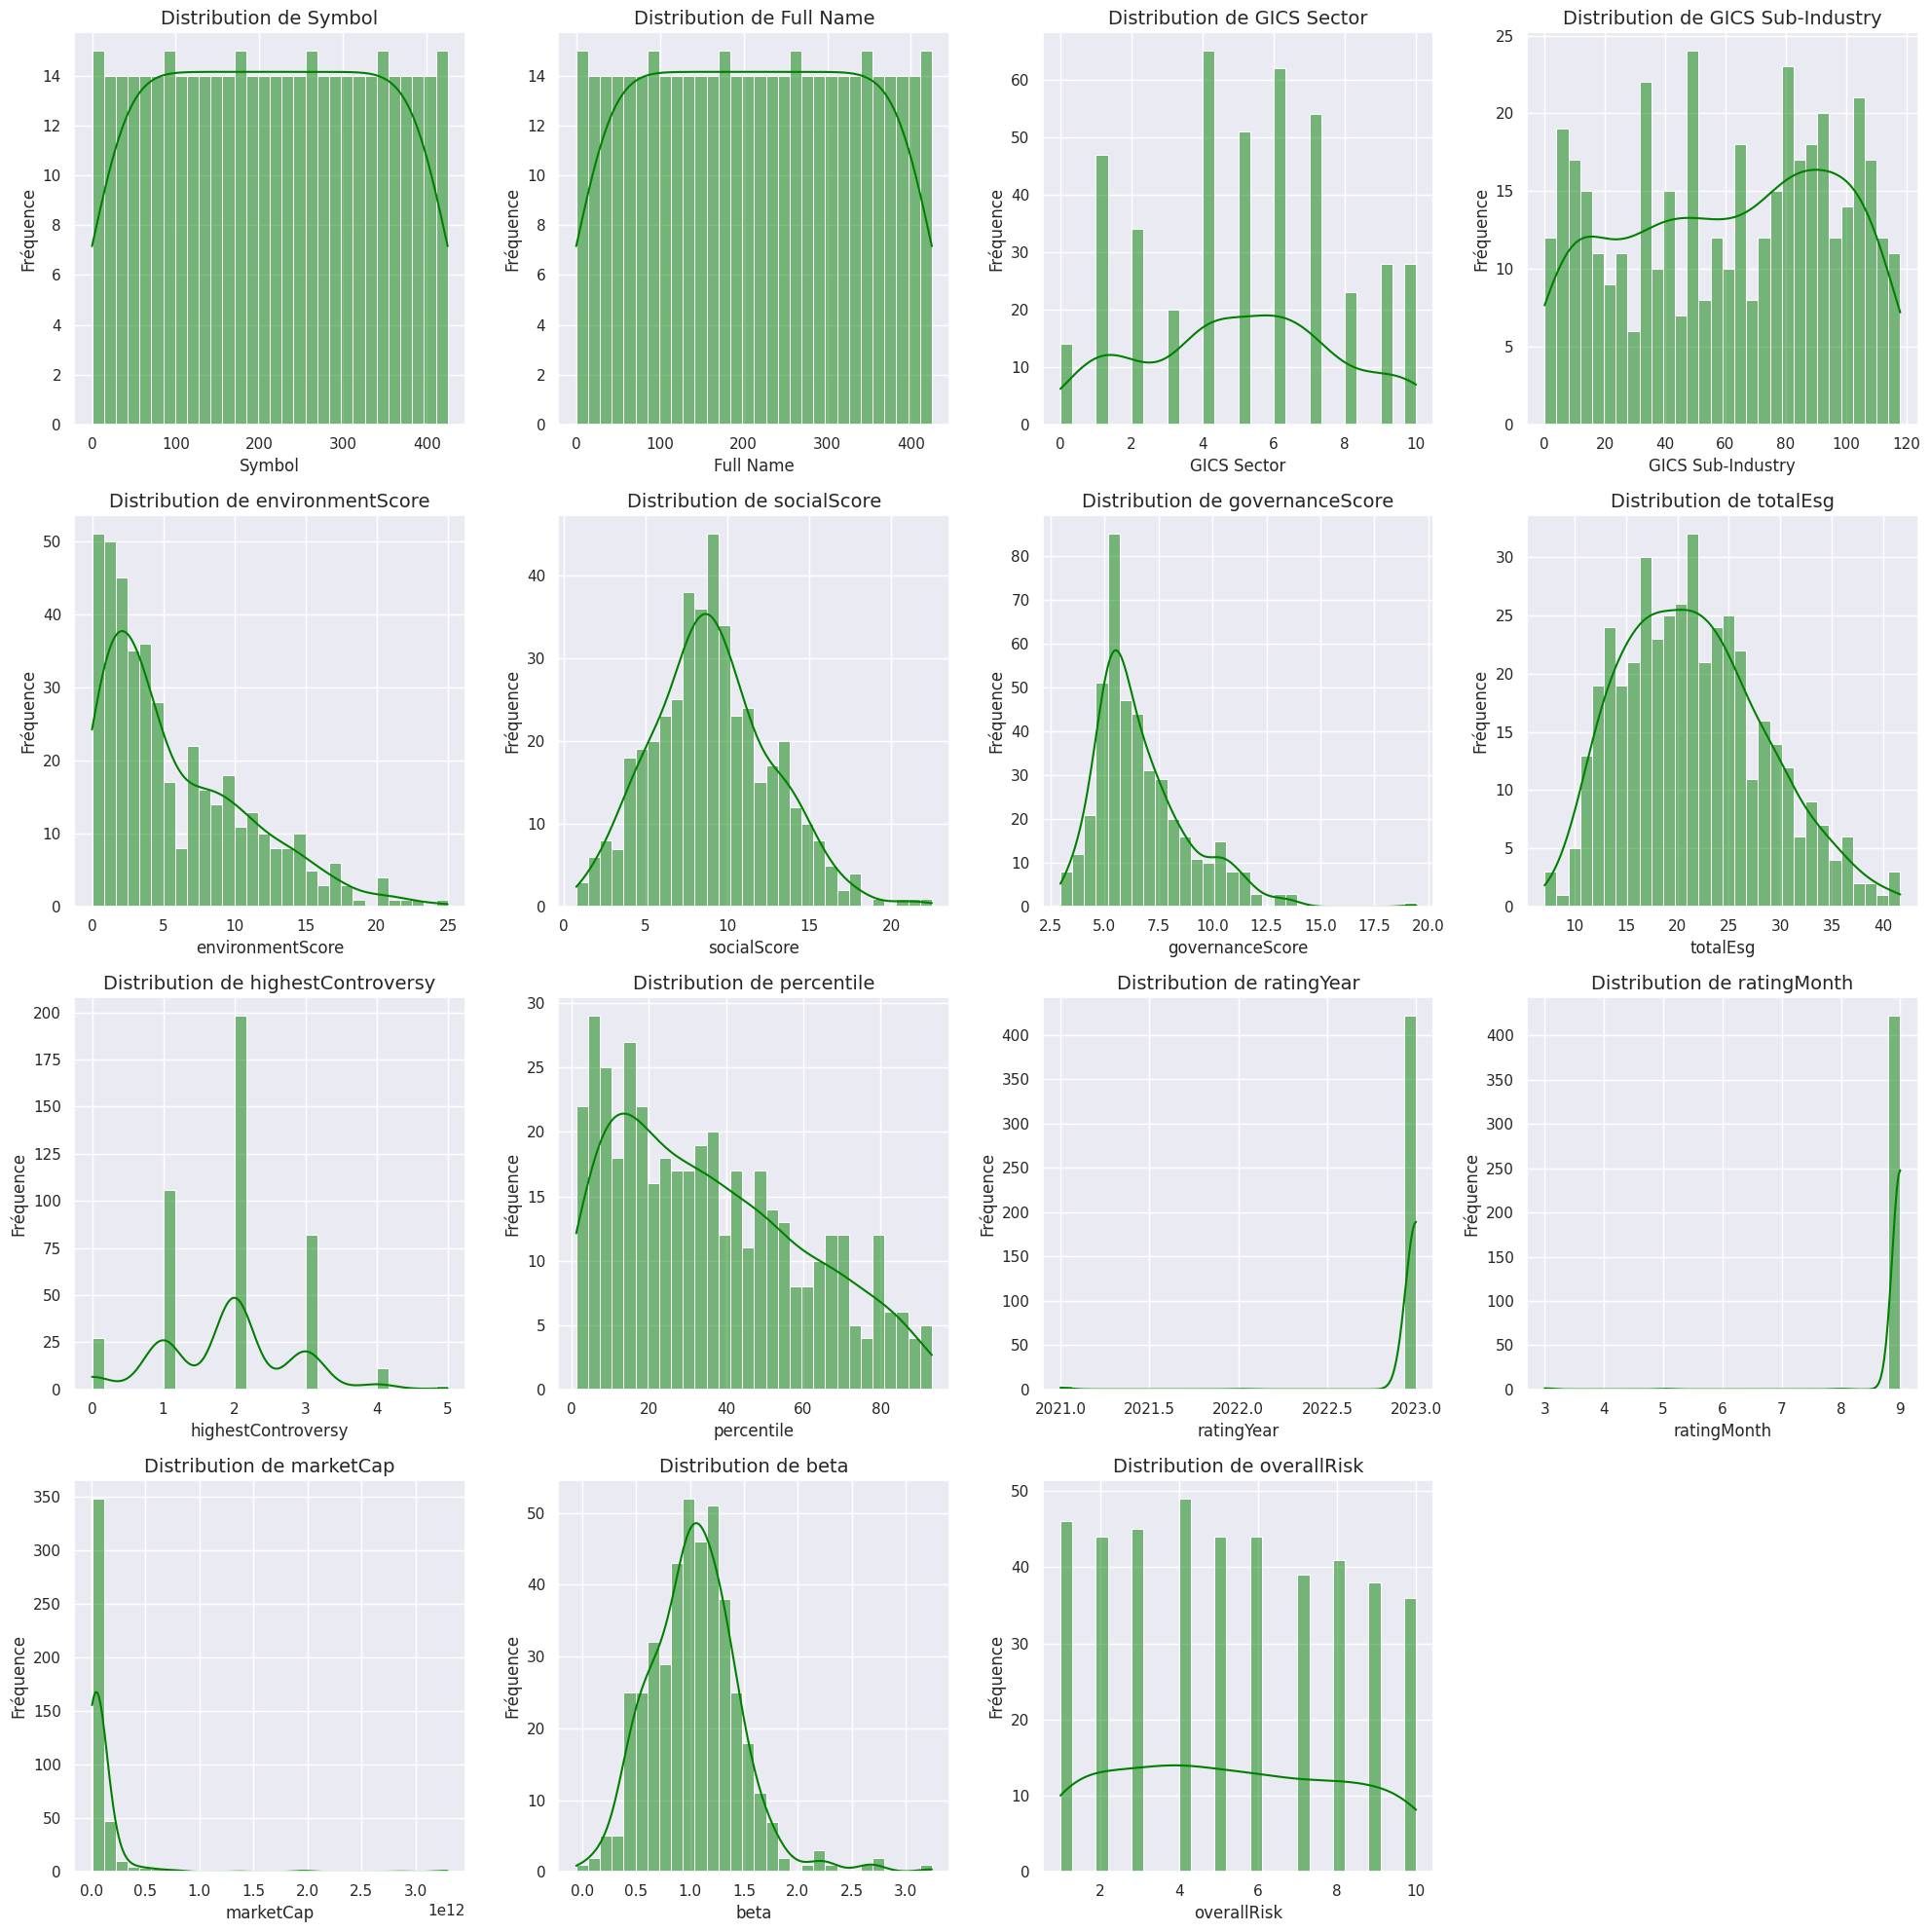

In [ ]:
# Sélectionner les colonnes numériques après encodage
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Définir la disposition des graphiques
graphs_per_row = 4
n_cols = graphs_per_row
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols  # Calculer le nombre de lignes nécessaires

# Créer une figure avec sous-graphiques
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()  # Aplatir la matrice d'axes pour un accès plus facile

# Générer les histogrammes pour chaque colonne numérique
for i, col in enumerate(numeric_columns):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30, color="green")
    axes[i].set_title(f"Distribution de {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Fréquence", fontsize=12)

# Supprimer les graphiques vides si le nombre de colonnes n'est pas un multiple de graphs_per_row
for i in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[i])

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

  

---


*  Distribution biaisée à gauche : environmentScore	,	governanceScore , percentile	, marketCap	.


*  Distribution biaisée à droite :ratingYear et	ratingMonth

*  Distribution légèrement asymétrique de beta avec une concentration autour 0,5 et 2


*   Distribution uniforme :	Symbol,	Full Name	,GICS Sector	,GICS Sub-Industry  et overallRisk . ( toutes les valeurs ont une fréquence égale. Ces colonnes sont inutiles pour la modélisation .)




---











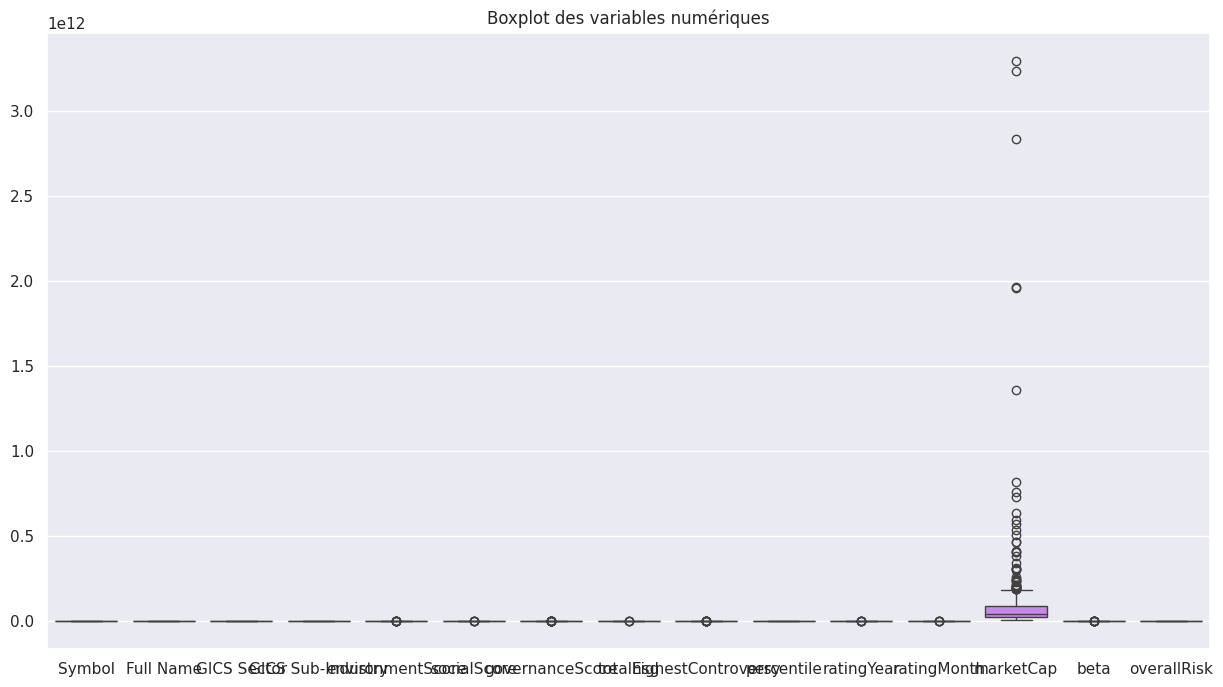

In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Créer un boxplot pour chaque colonne numérique
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_columns], orient='v')
plt.title("Boxplot des variables numériques")
plt.show()



---



*   On remarque  des outliers au niveau zéro dans le boxplot, elles peuvent être des points intéressants qui méritent une attention particulière.
*   Des outliers détectés dans la variable 'marketCap' :ces outliers indiquent des entreprises avec des capitalisations boursières exceptionnellement élevées par rapport aux autres.



---






# Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialiser le StandardScaler
scaler = StandardScaler()

# Appliquer la standardisation (Z-score)
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# Afficher les premières lignes après la standardisation
print(df.head())


     Symbol  Full Name  GICS Sector  GICS Sub-Industry  environmentScore  \
0 -1.727990  -1.646673    -0.022323           0.406605         -0.917134   
1 -1.719858  -1.549092     0.343432           0.870751          0.817112   
2 -1.711726  -1.451511     0.709187           1.450933         -1.046907   
3 -1.703595  -1.687331    -0.022323          -1.420971         -0.669384   
4 -1.695463  -1.679199    -0.022323          -0.376642         -0.691013   

   socialScore  governanceScore  totalEsg  highestControversy  percentile  \
0    -0.724519        -0.277875 -1.148832            0.129096   -1.144474   
1     0.704837        -0.897421  0.695708            0.129096    0.770798   
2    -0.459419         1.234002 -0.629284            1.228994   -0.739178   
3     2.218915         1.691726  1.215255            1.228994    1.353206   
4     1.412682         0.753160  0.475118            1.228994    0.515017   

   ratingYear  ratingMonth  marketCap      beta  overallRisk  
0    0.106354    

In [ ]:
# Vérification de la moyenne et de l'écart-type après standardisation
print("\nMoyenne et écart-type après standardisation :")
print(df[numeric_columns].mean())  # Moyenne de chaque colonne
print(df[numeric_columns].std())   # Ecart-type de chaque colonn


Moyenne et écart-type après standardisation :
Symbol                0.000000e+00
Full Name             0.000000e+00
GICS Sector           1.000764e-16
GICS Sub-Industry     7.505733e-17
environmentScore      1.667941e-17
socialScore          -1.334353e-16
governanceScore      -1.667941e-16
totalEsg             -2.272569e-16
highestControversy   -5.420807e-17
percentile           -9.799152e-17
ratingYear            3.385669e-13
ratingMonth          -1.893113e-15
marketCap            -8.339703e-18
beta                 -5.837792e-17
overallRisk          -1.501147e-16
dtype: float64
Symbol                1.001176
Full Name             1.001176
GICS Sector           1.001176
GICS Sub-Industry     1.001176
environmentScore      1.001176
socialScore           1.001176
governanceScore       1.001176
totalEsg              1.001176
highestControversy    1.001176
percentile            1.001176
ratingYear            1.001176
ratingMonth           1.001176
marketCap             1.001176
beta      




---



*   La standardisation a été correctement effectuée, car la moyenne est proche de 0 et l'écart-type est proche de 1 pour toutes les variables concernées.


---



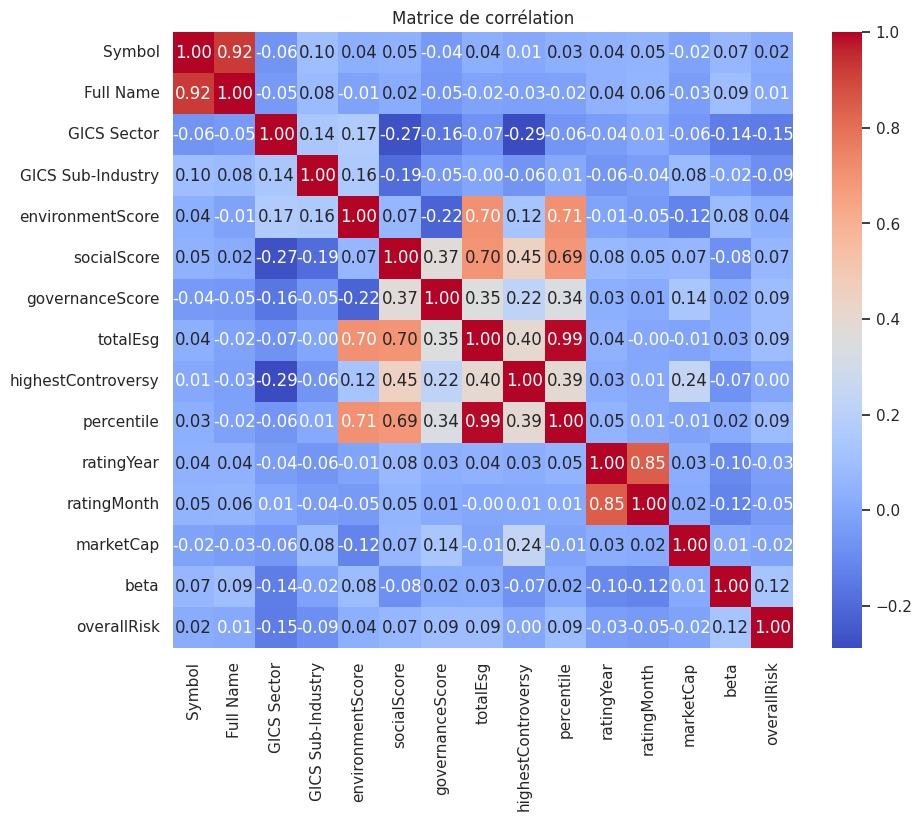

In [ ]:
# Matrice de corrélation
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()



---


*   Des Corrélations fortes et positive entre Symbol et FullName , entre totalEsg et percentile et entre  ratingYear et ratingMonth
*   Des Corrélations modérées entre  GICS Sector et GICS Sub-Industry l, les scores ESG (environmentScore, socialScore, governanceScore) sont modérément corrélés entre eux: Cela suggère que ces différents aspects de la performance ESG sont liés.


*   Corrélations faibles ou nulles entre marketCap et scores ESG : La faible corrélation entre la capitalisation boursière et les scores ESG montre que la taille d'une entreprise n'est pas un facteur déterminant de sa performance ESG.


---



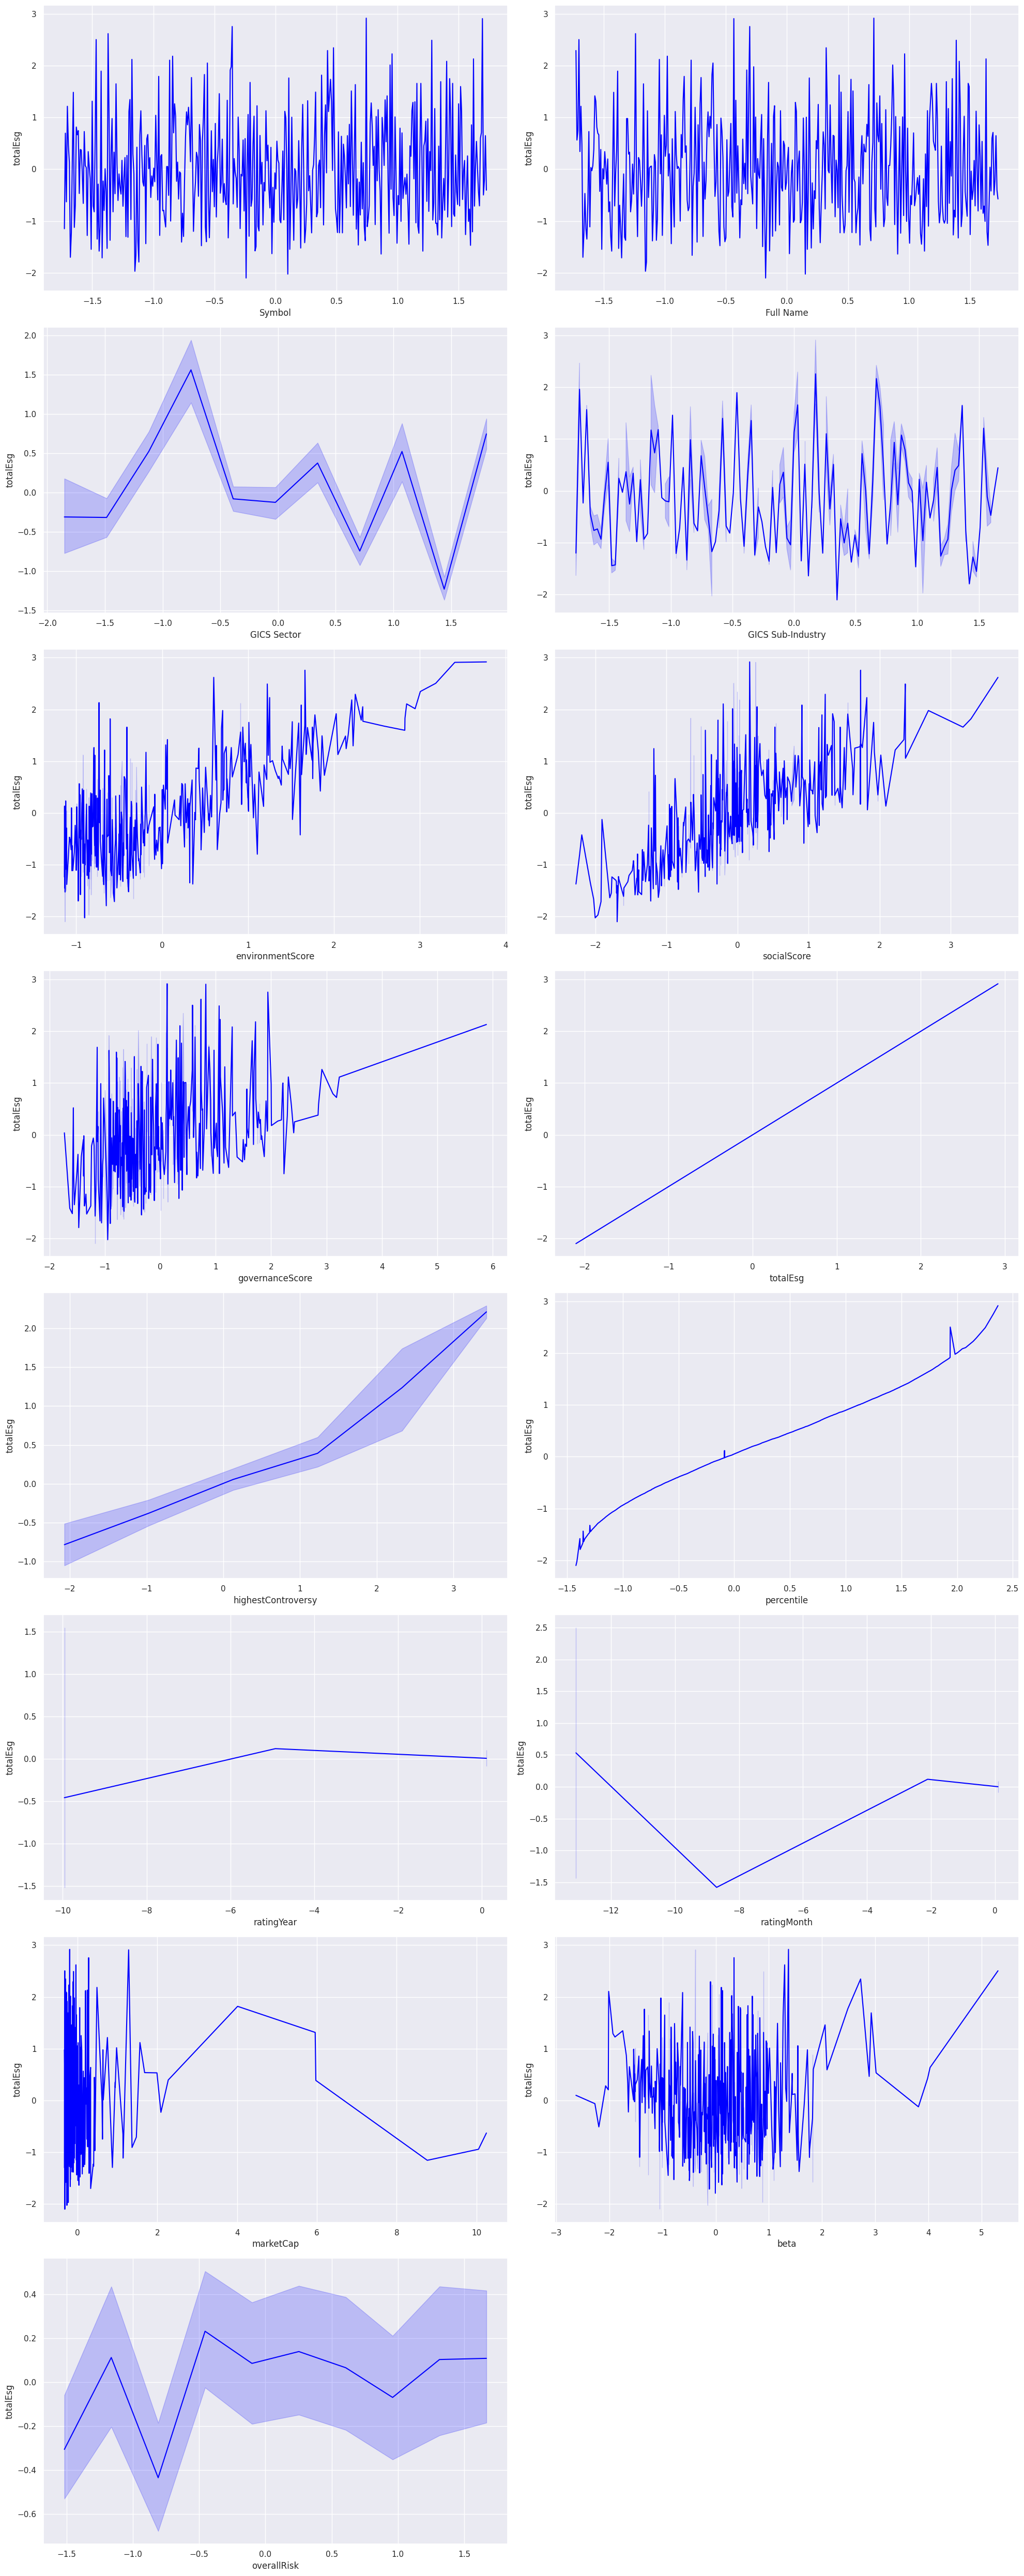

In [ ]:
col_names = df.columns[:15]

sns.set(rc={'figure.figsize': (20, 50)})

for i, column in enumerate(col_names, 1):
    plt.subplot(8, 2, i)  # Grille adaptée pour 15 colonnes (8 lignes x 2 colonnes)
    sns.lineplot(x=column, y='totalEsg', data=df, color='blue')  # Relation entre chaque colonne et 'totalEsg'

plt.tight_layout()
plt.show()





---





*  les  relations Linéaires : environmentScore ,  socialScore , governanceScore , highestControversy et percentile.





---




In [ ]:
# Liste des variables à conserver
variables_to_keep = ['totalEsg' ,'environmentScore', 'socialScore', 'governanceScore']

# Filtrer uniquement ces colonnes dans le DataFrame
df = df[variables_to_keep]

# Vérifier les colonnes restantes
print("Colonnes restantes :", df.columns.tolist())

Colonnes restantes : ['totalEsg', 'environmentScore', 'socialScore', 'governanceScore']


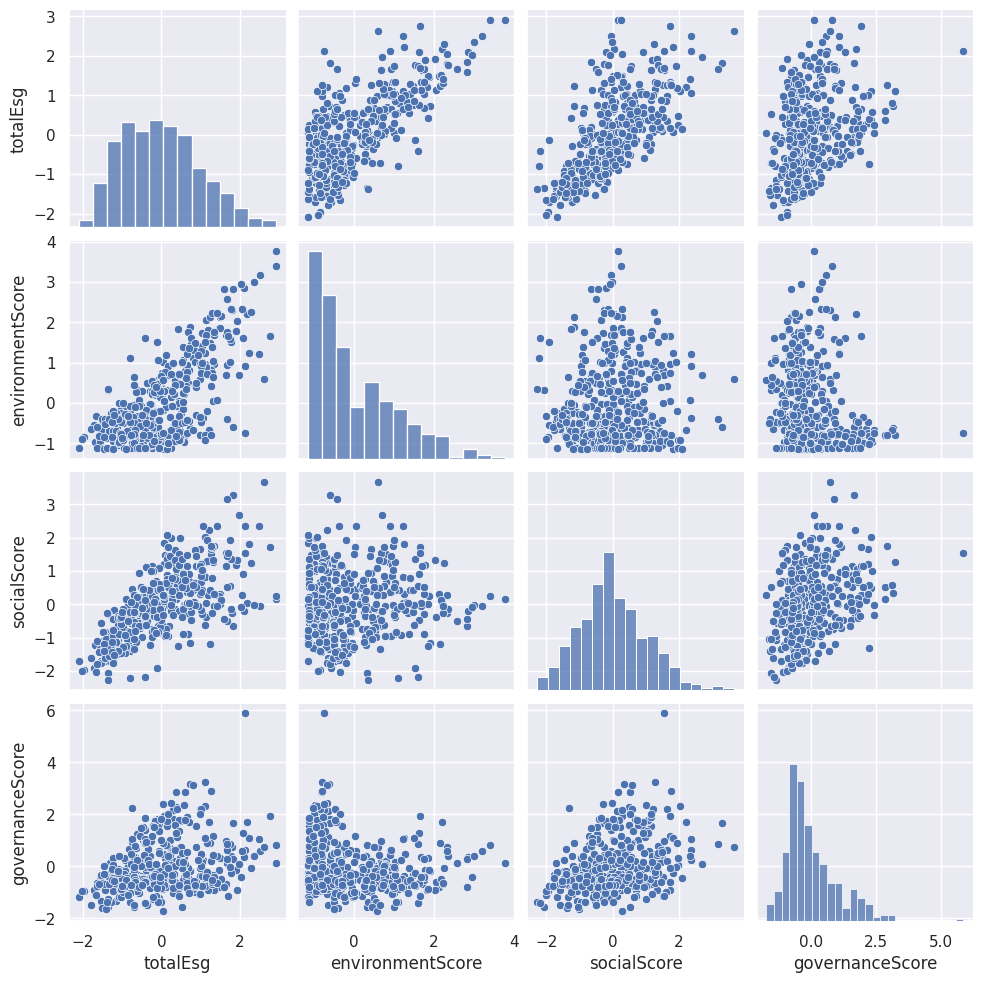

In [ ]:
sns.pairplot(df)
plt.show()

#Modeling

*Regression*

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
X = df.drop(columns=['totalEsg'])
y = df['totalEsg']
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Taille de l'ensemble d'entraînement :", X_train.shape)
print("Taille de l'ensemble de test :", X_test.shape)

Taille de l'ensemble d'entraînement : (340, 3)
Taille de l'ensemble de test : (86, 3)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

# Faire des prédictions
y_pred = model.predict(X_test)

# Évaluer le modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Coefficients :", model.coef_)
print("Intercept :", model.intercept_)
print("Mean Squared Error :", mse)
print("R2 Score :", r2)


Coefficients : [0.73800811 0.53094975 0.31389357]
Intercept : 9.680585000615416e-06
Mean Squared Error : 8.12067308458488e-07
R2 Score : 0.9999990319698767




*   Les Coefficients : Les valeurs plus élevées des coefficients indiquent une plus grande influence de la variable correspondante.

*   Intercept :L'intercept est la valeur prédite pour la cible lorsque toutes les variables indépendantes sont égales à zéro. Ici, la valeur proche de zéro (9.68e-06) indique que le modèle ne prédit presque rien en l'absence de contributions des variables indépendantes.


*  Mean Squared Error : Une valeur très faible comme ici indique que les prédictions du modèle sont très proches des valeurs réelles.
*R2 Score:Une valeur très proche de 1 (comme ici) suggère que le modèle explique presque toute la variation dans les données, indiquant une excellente adéquation.
     

*  ce modèle semble extrêmement performant. Toutefois, une performance aussi élevée peut aussi signaler un risque de surapprentissage (overfitting).









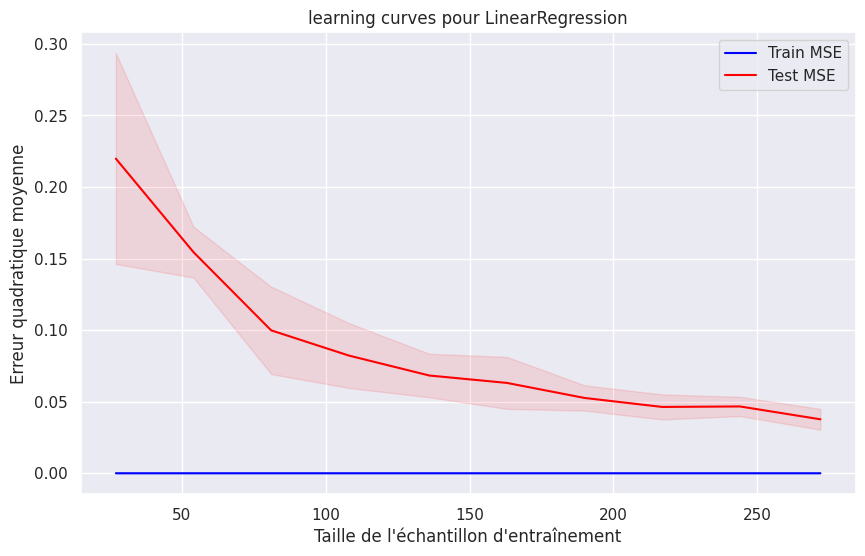

In [ ]:

from sklearn.model_selection import learning_curve

# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5,
                                                         scoring='neg_mean_squared_error',
                                                         train_sizes=np.linspace(0.1, 1.0, 10))

# Moyenne et écart-type des scores
train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Tracer les courbes d'apprentissage
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train MSE', color='blue')
plt.plot(train_sizes, test_mean, label='Test MSE', color='red')

# Tracer l'écart-type
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

plt.title("learning curves pour LinearRegression")
plt.xlabel('Taille de l\'échantillon d\'entraînement')
plt.ylabel('Erreur quadratique moyenne')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.linear_model import Ridge

# Appliquer Ridge Regression avec un hyperparamètre alpha
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Faire des prédictions et évaluer
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error :", mse)
print("R2 Score :", r2)


Mean Squared Error : 7.385984146858439e-06
R2 Score : 0.9999911954895



*   Avec l'ajustement des hyperparamètres, le MSE est légèrement plus élevé (bien que toujours très faible) et le R2 est également légèrement plus bas, ce qui peut signifier que le modèle est un peu plus "conservateur" dans son ajustement. Ce changement peut suggérer une meilleure généralisation, bien que l'impact soit minime dans ce cas précis.








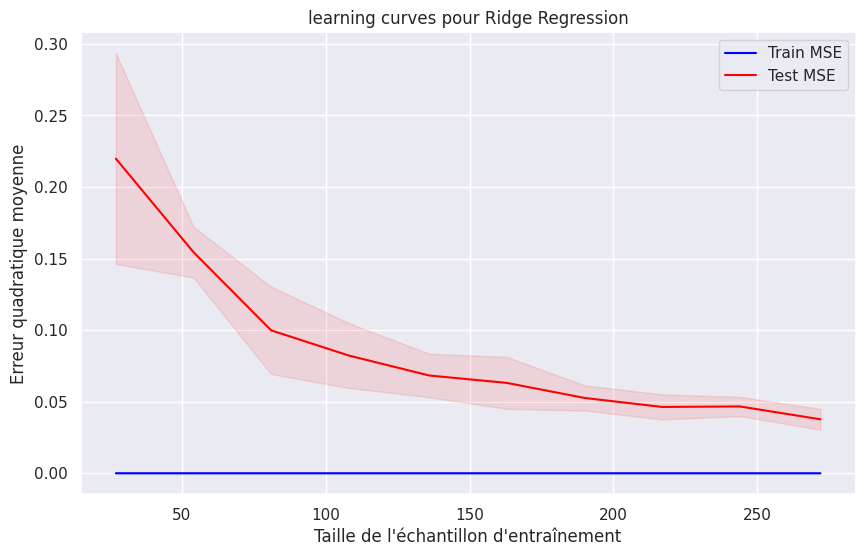

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, learning_curve
# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5,
                                                         scoring='neg_mean_squared_error',
                                                         train_sizes=np.linspace(0.1, 1.0, 10))

# Moyenne et écart-type des scores
train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Tracer les courbes d'apprentissage
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train MSE', color='blue')
plt.plot(train_sizes, test_mean, label='Test MSE', color='red')

# Tracer l'écart-type
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

plt.title("learning curves pour Ridge Regression")
plt.xlabel('Taille de l\'échantillon d\'entraînement')
plt.ylabel('Erreur quadratique moyenne')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
# Modèle pour la régression
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Entraîner le modèle
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation (par exemple, Erreur Quadratique Moyenne)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print("R2 Score :", r2)



Mean Squared Error: 0.03143592818498255
R2 Score : 0.9999990319698767




*   Mean Squared Error : la valeur est très faible, ce qui indique que le modèle est capable de prédire les valeurs cibles avec une grande précision.
*   R2 Score: Une valeur de 0.999999 signifie que 99,9999% de la variance des données cibles est expliquée par votre modèle, ce qui indique une performance exceptionnelle.


*  ce modèle semble extrêmement performant. Toutefois, une performance aussi élevée peut aussi signaler un risque de surapprentissage (overfitting).






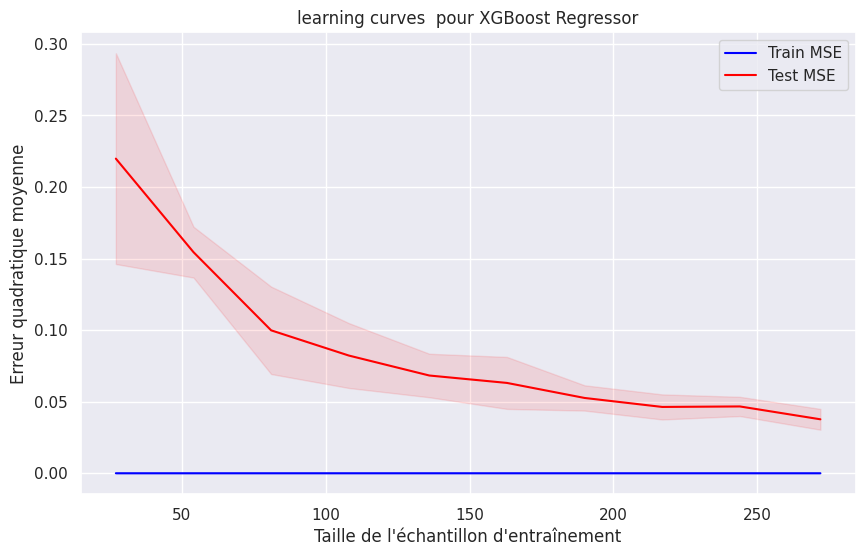

In [ ]:

from sklearn.model_selection import train_test_split, learning_curve

# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5,
                                                         scoring='neg_mean_squared_error',
                                                         train_sizes=np.linspace(0.1, 1.0, 10))

# Moyenne et écart-type des scores
train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Tracer les courbes d'apprentissage
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train MSE', color='blue')
plt.plot(train_sizes, test_mean, label='Test MSE', color='red')

# Tracer l'écart-type
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

plt.title("learning curves  pour XGBoost Regressor")
plt.xlabel('Taille de l\'échantillon d\'entraînement')
plt.ylabel('Erreur quadratique moyenne')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
##amelioration du modele
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

# Modèle de régression XGBoost avec hyperparamètres ajustés
model = XGBRegressor(objective='reg:squarederror', random_state=42)

# GridSearch pour trouver les meilleurs hyperparamètres
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 6],
    'subsample': [0.8, 0.9, 1],
    'colsample_bytree': [0.8, 0.9, 1],
    'lambda': [0, 1, 10],
    'alpha': [0, 1, 10]
}

# Recherche par grille
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, verbose=1)
grid_search.fit(X_train, y_train)

# Meilleurs paramètres trouvés
print(f"Meilleurs paramètres : {grid_search.best_params_}")

# Prédictions avec le meilleur modèle
y_pred = grid_search.best_estimator_.predict(X_test)

# Calcul de l'erreur quadratique moyenne (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print("R2 Score :", r2)


Fitting 3 folds for each of 2187 candidates, totalling 6561 fits
Meilleurs paramètres : {'alpha': 0, 'colsample_bytree': 0.8, 'lambda': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Mean Squared Error: 0.009242826336499197
R2 Score : 0.9999911954895


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,




*   Mean Squared Error :est beaucoup plus faible, ce qui signifie que le modèle avec hyperparamétrage fait de meilleures prédictions.
*   R2 Score : le R2 reste élevé, mais légèrement plus bas que le modèle sans hyperparamétrage. Cette légère baisse du R2 peut être interprétée comme un signe que le modèle avec hyperparamétrage est un peu plus conservateur dans son ajustement, cherchant à éviter le surapprentissage et à mieux généraliser aux nouvelles données.



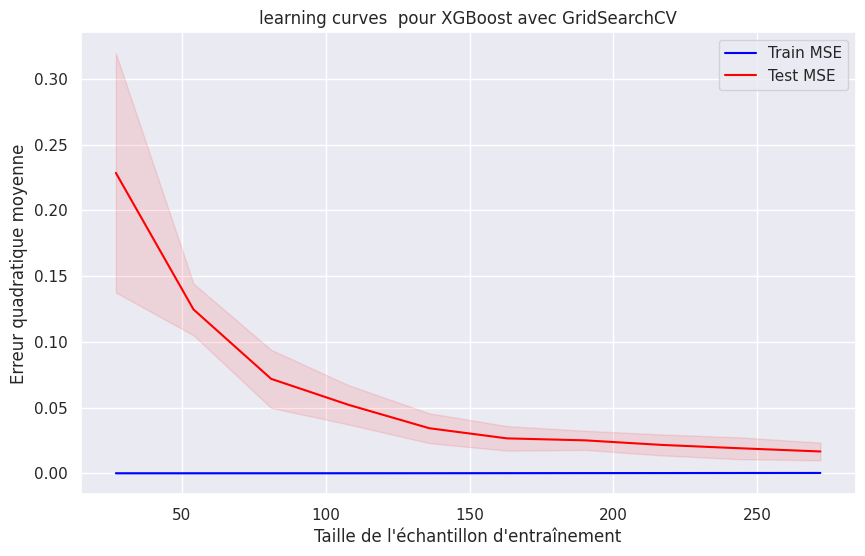

In [ ]:
from sklearn.model_selection import learning_curve
# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(grid_search.best_estimator_, X_train, y_train, cv=5,
                                                         scoring='neg_mean_squared_error',
                                                         train_sizes=np.linspace(0.1, 1.0, 10))

# Moyenne et écart-type des scores
train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Tracer les courbes d'apprentissage
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train MSE', color='blue')
plt.plot(train_sizes, test_mean, label='Test MSE', color='red')

# Tracer l'écart-type
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

plt.title("learning curves  pour XGBoost avec GridSearchCV")
plt.xlabel('Taille de l\'échantillon d\'entraînement')
plt.ylabel('Erreur quadratique moyenne')
plt.legend()
plt.grid(True)
plt.show()